<a href="https://colab.research.google.com/github/ShamimtheAnalyst/Crash-Course/blob/main/Tidyverse_Mastery.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## __Tidyverse Mastery: Select, Filter & Mutate for Beginners__

### __এই লেসন থেকে আমরা কী শিখব?__
ডেটা সায়েন্সে গ্রাফ তৈরির আগে ডেটাকে নিজের প্রয়োজন অনুযায়ী সাজিয়ে নেওয়া সবচেয়ে গুরুত্বপূর্ণ কাজ। এই নোটবুকটি পড়ার পর আপনি শিখবেন:

- Select: কীভাবে শত শত কলাম থেকে শুধু পছন্দের কলামগুলো আলাদা করতে হয়।
- Filter: কীভাবে নির্দিষ্ট শর্ত দিয়ে অপ্রয়োজনীয় ডেটা বাদ দিতে হয়।
- Mutate: কীভাবে ডেটাসেটে নেই এমন নতুন তথ্য অংকের মাধ্যমে তৈরি করতে হয়।
- Group_by: কীভাবে প্রতিটি প্রজাতির জন্য আলাদাভাবে ক্যালকুলেশন করতে হয়।

#### __প্রয়োজনীয় লাইব্রেরি লোড করা__
আমরা tidyverse প্যাকেজটি ব্যবহার করব যার মধ্যে dplyr (ডেটা ম্যানিপুলেশন) এবং ggplot2 (ভিজ্যুয়ালাইজেশন) দুটিই অন্তর্ভুক্ত।

In [ ]:
library(tidyverse)

# আমরা বিল্ট-ইন 'iris' ডেটাসেটটি ব্যবহার করব
head(iris)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
1,5.1,3.5,1.4,0.2,setosa
2,4.9,3.0,1.4,0.2,setosa
3,4.7,3.2,1.3,0.2,setosa
4,4.6,3.1,1.5,0.2,setosa
5,5.0,3.6,1.4,0.2,setosa
6,5.4,3.9,1.7,0.4,setosa


#### __স্টেপ ১: কলাম সিলেক্ট করা (Select)__
উদ্দেশ্য: আপনার কাছে অনেক তথ্য আছে, কিন্তু আপনি শুধু দুটো জিনিস দেখতে চান: ফুলের সেপাল লম্বা নাকি চওড়া।

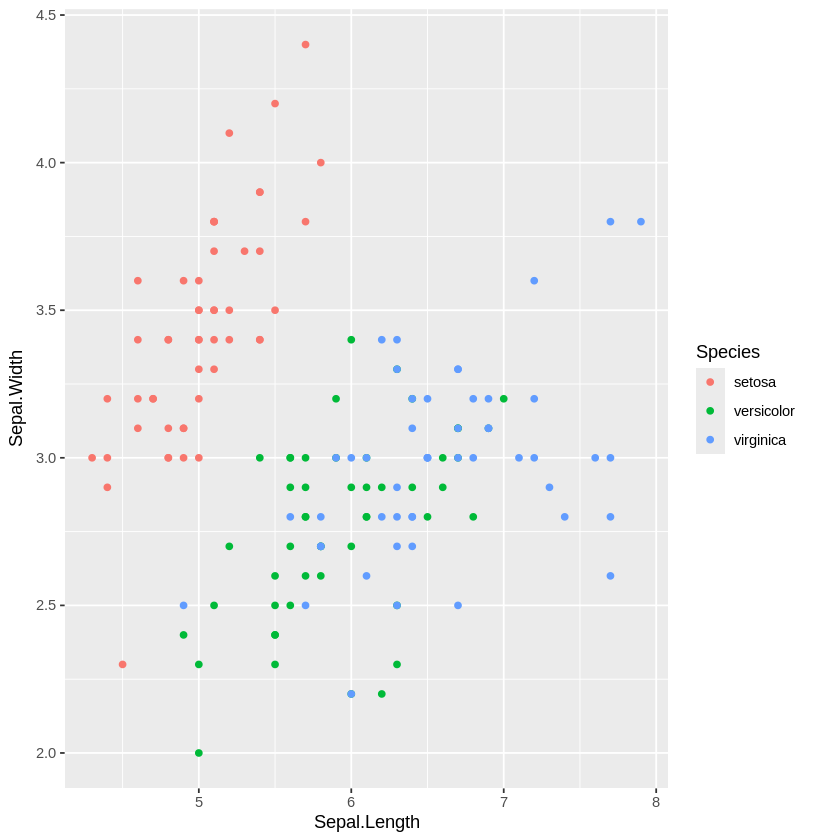

In [ ]:
# শুধু দরকারি কলামগুলো বেছে নেওয়া
iris %>%
  select(Species, Sepal.Length, Sepal.Width) %>%
  ggplot(aes(x = Sepal.Length, y = Sepal.Width, color = Species)) +
  geom_point()

__ব্যাখ্যা:__ এখানে select() ফাংশনটি আপনার ডেটা ফ্রেমের অন্য সব কলাম ডিলিট করে দিয়ে শুধু এই তিনটি কলামকে (Species, Sepal.Length, Sepal.Width) প্লট করার জন্য পাঠিয়েছে। এটি ডেটাসেটকে লম্বালম্বিভাবে ছোট করে কাজ সহজ করে দেয়।

#### __স্টেপ ২: অপ্রয়োজনীয় ডেটা সরানো (Filter)__
উদ্দেশ্য: গ্রাফে যখন অনেক বেশি বিন্দু (Points) থাকে, তখন সব তথ্য বোঝা কঠিন হয়। আমরা শুধু সেই ফুলগুলো দেখতে চাই যাদের সেপাল ৫ সেন্টিমিটারের চেয়ে বড়।

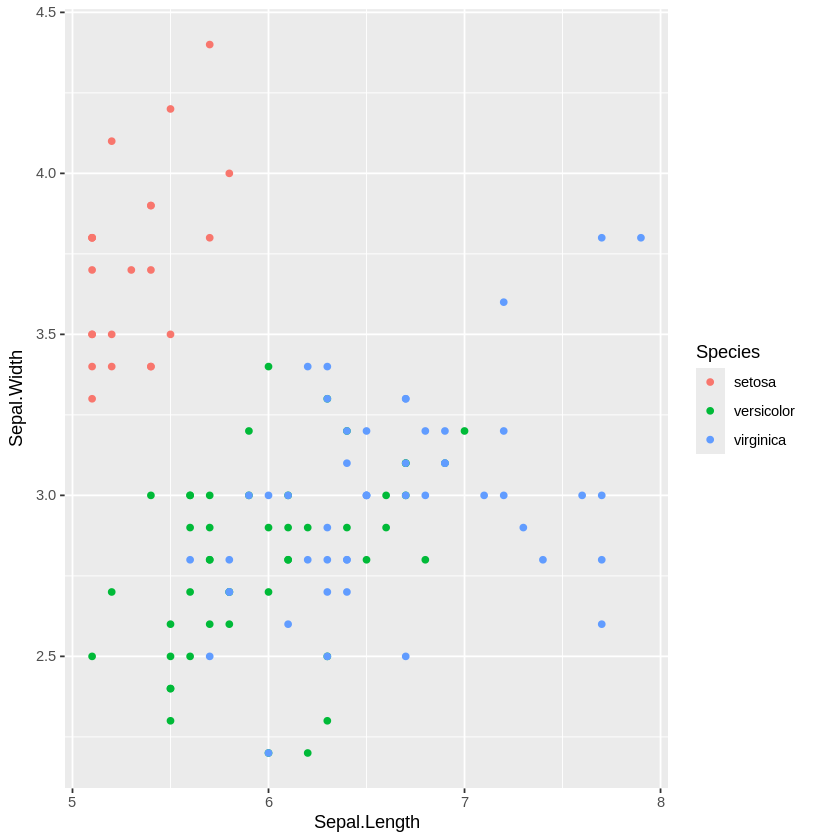

In [ ]:
# বড় সেপাল ওয়ালা ফুলগুলো ছেঁকে নেওয়া
iris %>%
  filter(Sepal.Length > 5.0) %>%
  ggplot(aes(x = Sepal.Length, y = Sepal.Width, color = Species)) +
  geom_point()

__ব্যাখ্যা:__ filter() ফাংশনটি ৫.০-এর নিচের সব সারি (Rows) ডেটা থেকে মুছে দিয়েছে। ফলে গ্রাফটি এখন আগের চেয়ে অনেক বেশি পরিষ্কার এবং আমরা শুধু বড় আকারের সেপালগুলোর প্যাটার্ন দেখতে পাচ্ছি।

#### __স্টেপ ৩: নতুন তথ্য তৈরি করা (Mutate)__
উদ্দেশ্য: এখন আপনি একটি নতুন কিছু দেখতে চান যা মূল ডেটাতে নেই। যেমন: সেপাল-এর ক্ষেত্রফল (Area = দৈর্ঘ্য × প্রস্থ)।

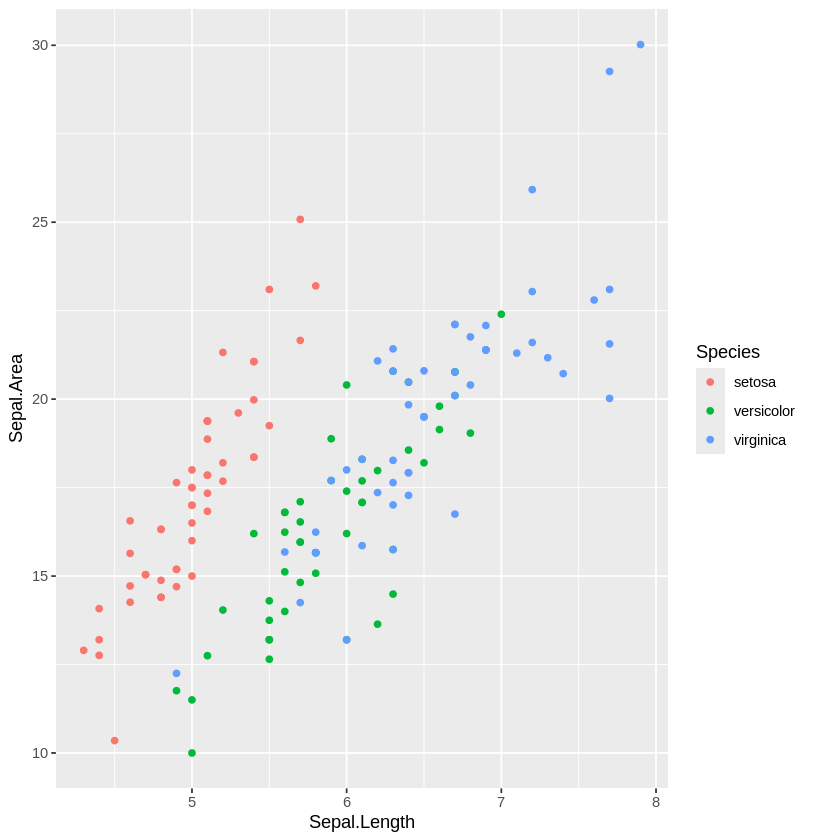

In [ ]:
# নতুন 'Area' কলাম তৈরি করে তা Y-অক্ষে বসানো
iris %>%
  mutate(Sepal.Area = Sepal.Length * Sepal.Width) %>%
  ggplot(aes(x = Sepal.Length, y = Sepal.Area, color = Species)) +
  geom_point()

__ব্যাখ্যা:__ mutate() একটি নতুন কলাম তৈরি করেছে যার নাম আমরা দিয়েছি Sepal.Area। আমরা এই নতুন নামটিকে সরাসরি ggplot-এর y অ্যাক্সিসে ব্যবহার করতে পেরেছি। এটি ডেটার ভেতরে নতুন কোনো গাণিতিক সম্পর্ক খুঁজে পেতে সাহায্য করে।

#### __স্টেপ ৪: প্রজাতি অনুযায়ী গ্রুপ করা (Group_by)__
উদ্দেশ্য: আমরা প্রতিটি প্রজাতির জন্য আলাদাভাবে কিছু তথ্য দেখতে চাই। যেমন: প্রতিটি প্রজাতির গড় দৈর্ঘ্য কত?

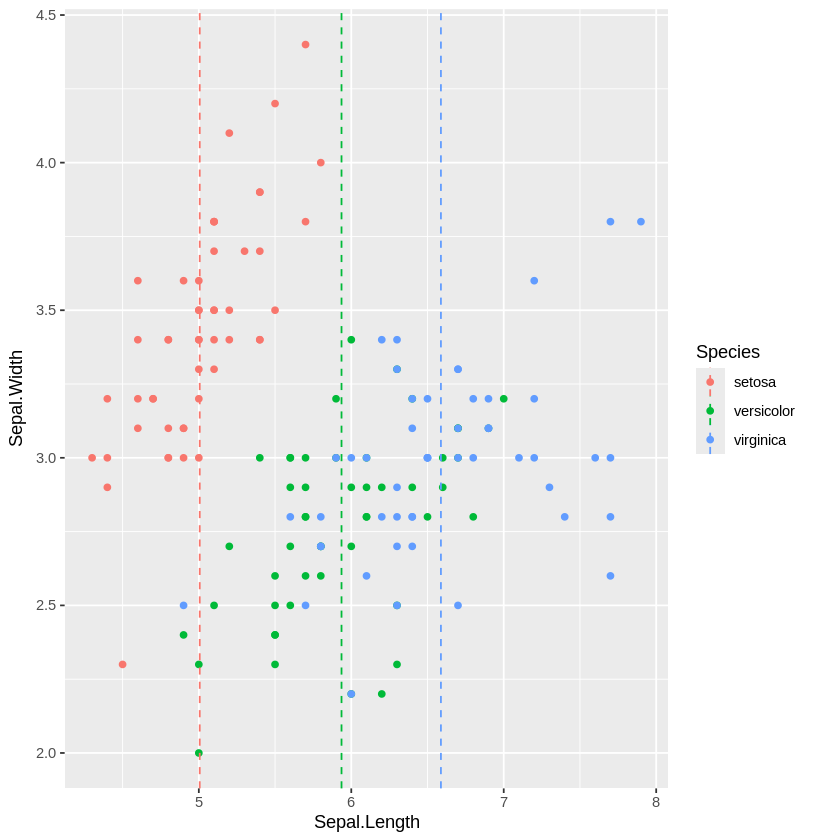

In [ ]:
# গ্রুপ করে প্রজাতির গড় বের করা (কিন্তু তথ্য না কমিয়ে)
iris %>%
  group_by(Species) %>%
  mutate(Avg_Length = mean(Sepal.Length)) %>%
  ggplot(aes(x = Sepal.Length, y = Sepal.Width, color = Species)) +
  geom_point() +
  geom_vline(aes(xintercept = Avg_Length, color = Species), linetype = "dashed")

__ব্যাখ্যা:__ এখানে group_by() ডেটাকে মনে মনে তিনটি দলে (Setosa, Versicolor, Virginica) ভাগ করেছে। এরপর mutate() প্রতিটি দলের জন্য আলাদাভাবে গড় (Mean) বের করেছে। শেষে geom_vline দিয়ে আমরা প্রতিটি প্রজাতির গড় দৈর্ঘ্যের ওপর একটি করে ড্যাশ লাইন বসিয়েছি, যা আমাদের বুঝতে সাহায্য করে কোন প্রজাতির ফুলগুলো সাধারণত বড় হয়।

#### __এক নজরে আপনার শেখা ৩টি সূত্র:__

- Select: লম্বালম্বি ছাঁটাই (Columns বাছাই)।
- Filter: আড়াআড়ি ছাঁটাই (নির্দিষ্ট শর্তে Rows বাছাই)।
- Mutate: নতুন অংক বা তথ্য যোগ করা (নতুন Variables তৈরি)।

__অভিনন্দন!__ আপনি এখন Tidyverse-এর মৌলিক শক্তি ব্যবহার করে ডেটাকে নিজের ইচ্ছেমতো নিয়ন্ত্রণ করতে পারেন। কাগল নোটবুকে এই কোডগুলো রান করে আপনি নিজেই আউটপুটগুলো যাচাই করে নিতে পারেন।